# Anomaly Detection Model - Bank Transaction Fraud Risk

Di notebook ini kita bangun model anomaly detection buat flagging transaksi yang berpotensi fraud.
Karena dataset ga punya label fraud, kita pake pendekatan unsupervised.

Model yang dipake:
- Isolation Forest (model utama)
- Local Outlier Factor / LOF (sebagai pembanding)

Evaluasi dilakuin secara kualitatif - kita bandingin profil transaksi yang di-flag sebagai anomali vs yang normal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv('../data/bank_transactions_data_2.csv')
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])
print(f'Loaded {len(df)} transactions')

Loaded 2512 transactions


## 1. Feature Engineering

Berdasarkan temuan di EDA, beberapa fitur yang relevan:

- **AmountToBalanceRatio**: transaksi yang terlalu gede relatif terhadap saldo itu suspicious
- **TxnHour**: transaksi dini hari bisa jadi indikator
- **DaysSincePrevTxn**: jarak dari transaksi sebelumnya
- **LoginAttempts**: nilai tinggi bisa indikasi brute force
- **TransactionDuration**: durasi yang terlalu cepet atau terlalu lama
- **Channel & TransactionType**: di-encode jadi numerik

In [3]:
# temporal features
df['TxnHour'] = df['TransactionDate'].dt.hour
df['TxnDayOfWeek'] = df['TransactionDate'].dt.dayofweek
df['DaysSincePrevTxn'] = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.total_seconds() / 86400

# ratio features
df['AmountToBalanceRatio'] = df['TransactionAmount'] / (df['AccountBalance'] + 1)

# flag: apakah transaksi terjadi di jam tidak wajar (00:00 - 05:59)
df['IsLateNight'] = (df['TxnHour'].between(0, 5)).astype(int)

# encode categorical
le_channel = LabelEncoder()
le_txntype = LabelEncoder()
le_occupation = LabelEncoder()

df['ChannelEncoded'] = le_channel.fit_transform(df['Channel'])
df['TxnTypeEncoded'] = le_txntype.fit_transform(df['TransactionType'])
df['OccupationEncoded'] = le_occupation.fit_transform(df['CustomerOccupation'])

print('Features created')
df[['TxnHour', 'DaysSincePrevTxn', 'AmountToBalanceRatio', 'IsLateNight', 'ChannelEncoded']].describe()

Features created


,TxnHour,DaysSincePrevTxn,AmountToBalanceRatio,IsLateNight,ChannelEncoded
count,2512.000000,2512.000000,2512.000000,2512.0,2512.000000
mean,16.626194,-487.484160,0.199483,0.0,0.991242
std,0.731059,106.379684,0.509109,0.0,0.809100
min,16.000000,-671.674398,0.000045,0.0,0.000000
25%,16.000000,-580.658111,0.018153,0.0,0.000000
50%,16.000000,-485.597951,0.051866,0.0,1.000000
75%,17.000000,-394.559740,0.151584,0.0,2.000000
max,18.000000,-307.572812,7.819477,0.0,2.000000


In [4]:
# pilih fitur untuk model
feature_cols = [
    'TransactionAmount',
    'TransactionDuration',
    'LoginAttempts',
    'AccountBalance',
    'CustomerAge',
    'TxnHour',
    'TxnDayOfWeek',
    'DaysSincePrevTxn',
    'AmountToBalanceRatio',
    'IsLateNight',
    'ChannelEncoded',
    'TxnTypeEncoded',
    'OccupationEncoded'
]

X = df[feature_cols].copy()

# handle missing/inf values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

print(f'Feature matrix shape: {X.shape}')
X.head()

Feature matrix shape: (2512, 13)


,TransactionAmount,TransactionDuration,LoginAttempts,AccountBalance,CustomerAge,TxnHour,TxnDayOfWeek,DaysSincePrevTxn,AmountToBalanceRatio,IsLateNight,ChannelEncoded,TxnTypeEncoded,OccupationEncoded
0,14.09,81,1,5112.21,70,16,1,-572.652014,0.002756,0,0,1,0
1,376.24,141,1,13758.91,68,16,1,-495.642546,0.027343,0,0,1,0
2,126.29,56,1,1122.35,19,18,0,-482.577037,0.112423,0,2,1,3
3,184.50,25,1,8569.06,26,16,4,-548.650637,0.021528,0,2,1,3
4,13.45,198,1,7429.40,26,17,0,-384.593924,0.001810,0,2,0,3


In [5]:
# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print('Scaling done')
X_scaled.describe().round(2)

Scaling done


,TransactionAmount,TransactionDuration,LoginAttempts,AccountBalance,CustomerAge,TxnHour,TxnDayOfWeek,DaysSincePrevTxn,AmountToBalanceRatio,IsLateNight,ChannelEncoded,TxnTypeEncoded,OccupationEncoded
count,2512.00,2512.00,2512.00,2512.00,2512.00,2512.00,2512.00,2512.00,2512.00,2512.0,2512.00,2512.00,2512.00
mean,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.0,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.0,1.00,1.00,1.00
min,-1.02,-1.57,-0.21,-1.29,-1.50,-0.86,-0.96,-1.73,-0.39,0.0,-1.23,-1.85,-1.34
25%,-0.74,-0.81,-0.21,-0.93,-0.99,-0.86,-0.96,-0.88,-0.36,0.0,-1.23,0.54,-1.34
50%,-0.30,-0.10,-0.21,-0.10,0.02,-0.86,-0.30,0.02,-0.29,0.0,0.01,0.54,-0.01
75%,0.40,0.59,-0.21,0.66,0.81,0.51,1.03,0.87,-0.09,0.0,1.25,0.54,1.32
max,5.56,2.58,6.43,2.53,1.99,1.88,1.69,1.69,14.97,0.0,1.25,0.54,1.32


## 2. Isolation Forest

Isolation Forest prinsipnya sederhana: anomali itu lebih gampang di-isolasi dibanding data normal.
Data point yang butuh lebih sedikit split buat terisolasi dianggap lebih anomalous.

Parameter yang dipake:
- `contamination=0.05`: asumsi sekitar 5% transaksi potentially anomalous
- `n_estimators=200`: cukup banyak tree buat stability
- `random_state=42`: biar reproducible

In [6]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

df['IsoForest_Pred'] = iso_forest.fit_predict(X_scaled)
df['IsoForest_Score'] = iso_forest.decision_function(X_scaled)

# -1 = anomaly, 1 = normal
n_anomalies = (df['IsoForest_Pred'] == -1).sum()
print(f'Isolation Forest detected {n_anomalies} anomalies ({n_anomalies/len(df)*100:.1f}%)')

Isolation Forest detected 126 anomalies (5.0%)


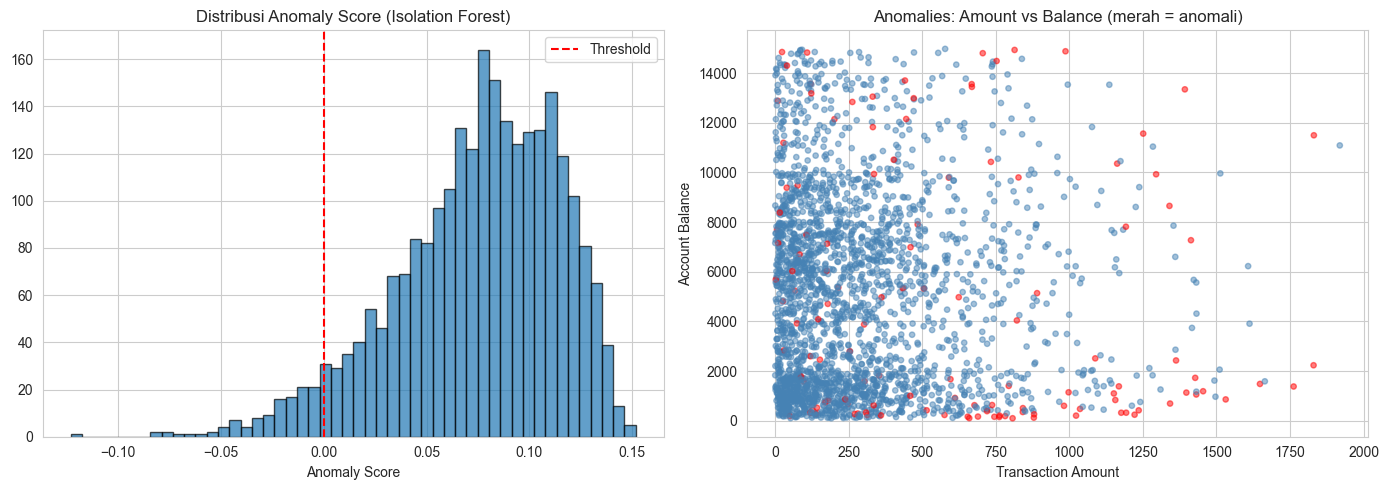

In [7]:
# distribusi anomaly score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['IsoForest_Score'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=df[df['IsoForest_Pred'] == -1]['IsoForest_Score'].max(), color='red', linestyle='--', label='Threshold')
axes[0].set_title('Distribusi Anomaly Score (Isolation Forest)')
axes[0].set_xlabel('Anomaly Score')
axes[0].legend()

colors = ['steelblue' if x == 1 else 'red' for x in df['IsoForest_Pred']]
axes[1].scatter(df['TransactionAmount'], df['AccountBalance'], c=colors, alpha=0.5, s=15)
axes[1].set_xlabel('Transaction Amount')
axes[1].set_ylabel('Account Balance')
axes[1].set_title('Anomalies: Amount vs Balance (merah = anomali)')

plt.tight_layout()
plt.show()

## 3. Local Outlier Factor (LOF)

LOF ngukur seberapa "isolated" suatu data point dibanding neighbors-nya.
Kita pake ini sebagai second opinion, buat validasi hasil Isolation Forest.

In [8]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    n_jobs=-1
)

df['LOF_Pred'] = lof.fit_predict(X_scaled)
df['LOF_Score'] = lof.negative_outlier_factor_

n_anomalies_lof = (df['LOF_Pred'] == -1).sum()
print(f'LOF detected {n_anomalies_lof} anomalies ({n_anomalies_lof/len(df)*100:.1f}%)')

LOF detected 126 anomalies (5.0%)


In [9]:
# perbandingan hasil kedua model
both_anomaly = ((df['IsoForest_Pred'] == -1) & (df['LOF_Pred'] == -1)).sum()
iso_only = ((df['IsoForest_Pred'] == -1) & (df['LOF_Pred'] == 1)).sum()
lof_only = ((df['IsoForest_Pred'] == 1) & (df['LOF_Pred'] == -1)).sum()

print(f'Flagged oleh kedua model: {both_anomaly}')
print(f'Hanya Isolation Forest: {iso_only}')
print(f'Hanya LOF: {lof_only}')
print(f'\nTotal unique anomalies (union): {both_anomaly + iso_only + lof_only}')

Flagged oleh kedua model: 55
Hanya Isolation Forest: 71
Hanya LOF: 71

Total unique anomalies (union): 197


In [10]:
# consensus: transaksi yang di-flag oleh kedua model lebih likely anomali
df['Consensus_Anomaly'] = ((df['IsoForest_Pred'] == -1) & (df['LOF_Pred'] == -1)).astype(int)

print(f'Consensus anomalies: {df["Consensus_Anomaly"].sum()}')

Consensus anomalies: 55


## 4. Analisis Karakteristik Anomali

Sekarang kita bandingin profil transaksi normal vs anomali.
Ini penting buat validasi apakah model nangkep pola yang make sense secara bisnis.

In [11]:
# profil anomali vs normal (berdasarkan Isolation Forest)
anomaly_df = df[df['IsoForest_Pred'] == -1]
normal_df = df[df['IsoForest_Pred'] == 1]

compare_cols = ['TransactionAmount', 'AccountBalance', 'TransactionDuration', 
                'LoginAttempts', 'CustomerAge', 'AmountToBalanceRatio', 'DaysSincePrevTxn']

comparison = pd.DataFrame({
    'Normal_Mean': normal_df[compare_cols].mean(),
    'Anomaly_Mean': anomaly_df[compare_cols].mean(),
    'Normal_Median': normal_df[compare_cols].median(),
    'Anomaly_Median': anomaly_df[compare_cols].median()
}).round(2)

comparison

,Normal_Mean,Anomaly_Mean,Normal_Median,Anomaly_Median
TransactionAmount,281.45,603.25,204.02,494.74
AccountBalance,5125.34,4905.21,4793.83,2486.68
TransactionDuration,118.55,140.42,111.00,129.00
LoginAttempts,1.05,2.62,1.00,2.00
CustomerAge,44.74,43.47,45.00,42.00
AmountToBalanceRatio,0.16,0.93,0.05,0.17
DaysSincePrevTxn,-487.24,-492.11,-484.13,-493.08


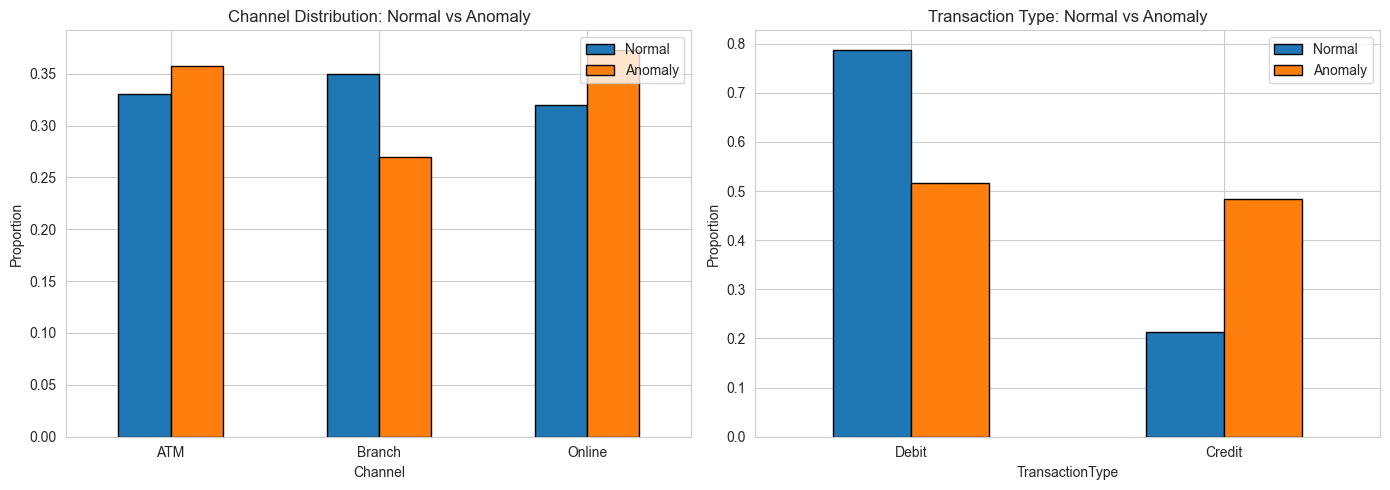

In [12]:
# distribusi channel dan transaction type pada anomali
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# channel distribution
channel_normal = normal_df['Channel'].value_counts(normalize=True)
channel_anomaly = anomaly_df['Channel'].value_counts(normalize=True)
channel_comp = pd.DataFrame({'Normal': channel_normal, 'Anomaly': channel_anomaly}).fillna(0)
channel_comp.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Channel Distribution: Normal vs Anomaly')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=0)

# transaction type distribution
type_normal = normal_df['TransactionType'].value_counts(normalize=True)
type_anomaly = anomaly_df['TransactionType'].value_counts(normalize=True)
type_comp = pd.DataFrame({'Normal': type_normal, 'Anomaly': type_anomaly}).fillna(0)
type_comp.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Transaction Type: Normal vs Anomaly')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

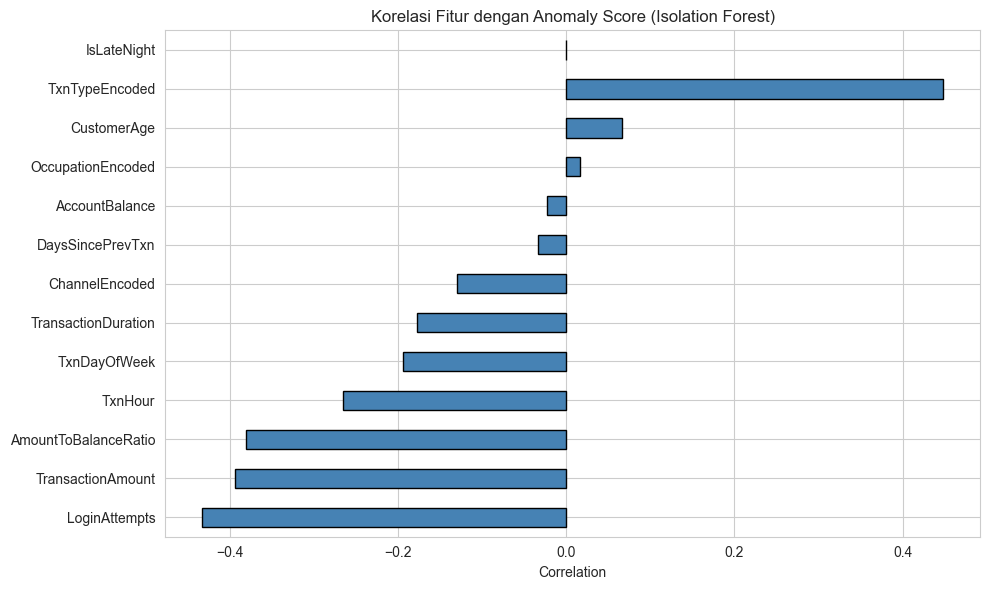

Fitur dengan korelasi negatif kuat = semakin tinggi nilainya, semakin anomalous


In [13]:
# feature importance: mana fitur yang paling berpengaruh terhadap anomaly score
# kita hitung korelasi antara tiap fitur dengan anomaly score
score_corr = X_scaled.copy()
score_corr['AnomalyScore'] = df['IsoForest_Score']
feat_importance = score_corr.corr()['AnomalyScore'].drop('AnomalyScore').sort_values()

plt.figure(figsize=(10, 6))
feat_importance.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Korelasi Fitur dengan Anomaly Score (Isolation Forest)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

print('Fitur dengan korelasi negatif kuat = semakin tinggi nilainya, semakin anomalous')

## 5. Thresholding

Selain pake contamination rate tetap, kita juga bisa atur threshold manual berdasarkan anomaly score.
Ini berguna kalau bisnis mau adjust sensitivity-nya.

In [14]:
# distribusi score dan berbagai threshold
percentiles = [1, 3, 5, 10]

print('Threshold analysis berdasarkan percentile anomaly score:')
print('-' * 60)
for p in percentiles:
    threshold = np.percentile(df['IsoForest_Score'], p)
    n_flagged = (df['IsoForest_Score'] <= threshold).sum()
    print(f'  Percentile {p}%: threshold={threshold:.4f}, flagged={n_flagged} transaksi ({n_flagged/len(df)*100:.1f}%)')

print('\nDengan contamination=0.05, model secara default menggunakan ~5th percentile sebagai cutoff.')

Threshold analysis berdasarkan percentile anomaly score:
------------------------------------------------------------
  Percentile 1%: threshold=-0.0343, flagged=26 transaksi (1.0%)
  Percentile 3%: threshold=-0.0126, flagged=76 transaksi (3.0%)
  Percentile 5%: threshold=0.0000, flagged=126 transaksi (5.0%)
  Percentile 10%: threshold=0.0199, flagged=252 transaksi (10.0%)

Dengan contamination=0.05, model secara default menggunakan ~5th percentile sebagai cutoff.


## 6. Save Model

Simpan model dan preprocessor buat dipake di API inference nanti.

In [15]:
os.makedirs('../models', exist_ok=True)

joblib.dump(iso_forest, '../models/isolation_forest.joblib')
joblib.dump(scaler, '../models/scaler.joblib')
joblib.dump(le_channel, '../models/le_channel.joblib')
joblib.dump(le_txntype, '../models/le_txntype.joblib')
joblib.dump(le_occupation, '../models/le_occupation.joblib')
joblib.dump(feature_cols, '../models/feature_cols.joblib')

print('Model artifacts saved to ../models/')
print(f'  - isolation_forest.joblib')
print(f'  - scaler.joblib')
print(f'  - le_channel.joblib, le_txntype.joblib, le_occupation.joblib')
print(f'  - feature_cols.joblib')

Model artifacts saved to ../models/
  - isolation_forest.joblib
  - scaler.joblib
  - le_channel.joblib, le_txntype.joblib, le_occupation.joblib
  - feature_cols.joblib


## 7. Kesimpulan

**Model:** Isolation Forest, contamination 5%.

**Kenapa model ini:**
- Cocok buat unsupervised anomaly detection
- Scalable dan efisien
- Hasil validasi kualitatif menunjukkan anomali yang ke-detect punya karakteristik yang masuk akal

**Feature engineering:**
- Temporal features (jam, hari, jarak antar transaksi)
- Ratio features (amount/balance)
- Behavioral flags (late night)
- Encoded categoricals

**Evaluasi:**
- Ga ada ground truth, jadi evaluasi kualitatif
- Cross-check dengan LOF menunjukkan overlap yang reasonable
- Threshold bisa di-tune sesuai risk appetite bisnis